<a href="https://colab.research.google.com/github/rinviriti/AI-ML-Learning-Journey/blob/main/08_machine_learning/%20breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Classification using Machine Learning

In this project, we will build a machine learning model to classify breast cancer tumors as malignant or benign.

This dataset is commonly used for learning medical AI and binary classification.

Learning Objectives:

- Load a medical dataset
- Explore dataset features
- Train a machine learning model
- Evaluate model performance
- Understand medical classification problems

In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

print(data.DESCR[:1000])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

## Dataset Overview

The dataset contains information about breast cancer tumors.

Target Classes:

- 0 = Malignant
- 1 = Benign

We will use these features to train a classifier.

In [2]:
import pandas as pd

df = pd.DataFrame(data.data, columns=data.feature_names)

df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nTarget Distribution:")

print(df["target"].value_counts())

Dataset Shape: (569, 31)

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


## Splitting the Dataset

Machine learning models must be tested on unseen data.

We split the dataset into:

- Training Set (80%)
- Testing Set (20%)

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)

y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


## Training a Random Forest Classifier

Random Forest combines multiple decision trees to improve prediction accuracy.

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model Prediction

In [6]:
y_pred = model.predict(X_test)

## Model Evaluation

Accuracy alone is not enough in medical applications.

We also examine:

- Precision
- Recall
- F1 Score
- Confusion Matrix

In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40  3]
 [ 1 70]]


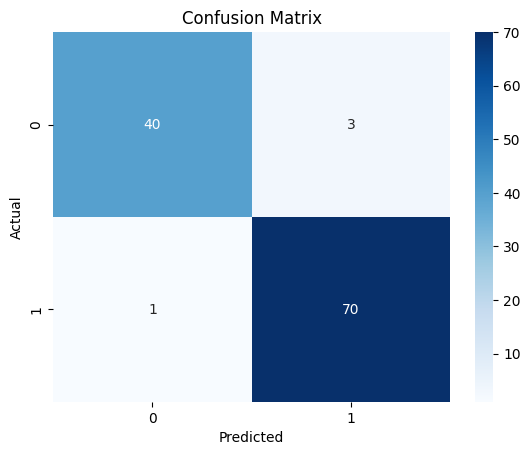

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Conclusion

In this project, we built a Random Forest classifier for breast cancer diagnosis.

Key Takeaways:

- Medical datasets can be analyzed using machine learning.
- Random Forest performs well on tabular medical data.
- Evaluation metrics such as precision, recall, and F1-score are important in healthcare applications.